<div style="border-top: 4px solid #b85300; border-bottom: 1px solid #b85300; padding: 40px 0 32px; margin-bottom: 8px;">
  <p style="font-family:'Courier New', monospace; font-size:0.7em; color:#b85300; text-transform:uppercase; letter-spacing:2px; margin:0 0 10px;">Lead University &nbsp;&middot;&nbsp; Minería de Datos I</p>
  <h1 style="font-family:'Palatino Linotype', Palatino, serif; font-size:2.3em; color:#000; margin:0 0 10px; font-weight:700; letter-spacing:0.3px;">Métodos No Supervisados</h1>
  <p style="font-family:'Palatino Linotype', Palatino, serif; font-size:1.05em; color:#444; margin:0; font-style:italic;">Reducción de Dimensionalidad &nbsp;&mdash;&nbsp; Calidad de Vino · winequality.csv</p>
</div>

<div style="margin: 40px 0 8px; border-left: 3px solid #b85300; padding-left: 16px;">
  <span style="font-family:'Courier New', monospace; font-size:0.75em; color:#b85300; text-transform:uppercase; letter-spacing:1.5px;">Configuración</span>
  <h2 style="font-family:'Palatino Linotype', Palatino, serif; font-size:1.35em; color:#000; margin:4px 0 0; font-weight:600;">Librerías e Importaciones</h2>
</div>

In [1]:
%matplotlib inline
import pandas as pd
import importlib

import scripts.Dataset_2 as winequality

import warnings
warnings.filterwarnings('ignore')

c:\Users\borge\OneDrive\Documentos\DATA_SCIENCE\LEAD UNIVERSITY\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<div style="border-top: 2px solid #b85300; margin-top: 48px; padding-top: 28px; margin-bottom: 1.4rem;">
  <span style="font-family:'Courier New', monospace; font-size:0.72em; color:#b85300; text-transform:uppercase; letter-spacing:1.5px;">Dataset 2</span>
  <h1 style="font-family:'Palatino Linotype', Palatino, serif; font-size:1.85em; color:#000; margin:6px 0 12px; font-weight:700;">winequality.csv</h1>
  <p style="font-size:0.94em; color:#555555; margin:0; line-height:1.7;">Dataset de calidad de vino con variables fisicoquímicas (acidez, azúcar residual, sulfatos, alcohol, etc.) y una variable objetivo de calidad discreta (escala 3–8). El reto es que las clases son continuas y adyacentes —especialmente calidad 5, 6 y 7— lo que dificulta la separación clara en espacios de baja dimensión.</p>
</div>

In [2]:
df2 = pd.read_csv('data/winequality.csv')

# Exploración básica
print('Shape:', df2.shape)
print('\nDistribución por calidad:')
print(df2['calidad'].value_counts().sort_index())
print('\nValores nulos:', df2.isnull().sum().sum())
print('\nEstadísticas descriptivas:')
df2.describe()

Shape: (1599, 12)

Distribución por calidad:
calidad
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

Valores nulos: 0

Estadísticas descriptivas:


,fija.acidez,volatil.acidez,citrica.acidez,residual.azucar,cloruros,libre.sulfuro.dioxido,total.sulfuro.dioxido,densidad,pH,sulfitos,alcohol,calidad
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


<div style="margin: 40px 0 8px; border-left: 3px solid #b85300; padding-left: 16px;">
  <span style="font-family:'Courier New', monospace; font-size:0.75em; color:#b85300; text-transform:uppercase; letter-spacing:1.5px;">Fase 1</span>
  <h2 style="font-family:'Palatino Linotype', Palatino, serif; font-size:1.35em; color:#000; margin:4px 0 0; font-weight:600;">Comparación 2D — ACP vs t-SNE vs UMAP</h2>
</div>

Varianza explicada por componente: [0.28173931 0.1750827  0.1409585 ]
Varianza explicada acumulada: 0.5978
Silhouette score (ACP): -0.0531
Silhouette score (t-SNE): -0.0971
Silhouette score por cantidad de vecinos: {5: -0.14342273771762848, 10: -0.1293260157108307, 15: -0.11989367008209229, 20: -0.11745196580886841, 30: -0.1203043982386589, 50: -0.11716680973768234}
Mejor cantidad de vecinos: 50 (silhouette score: -0.1172)


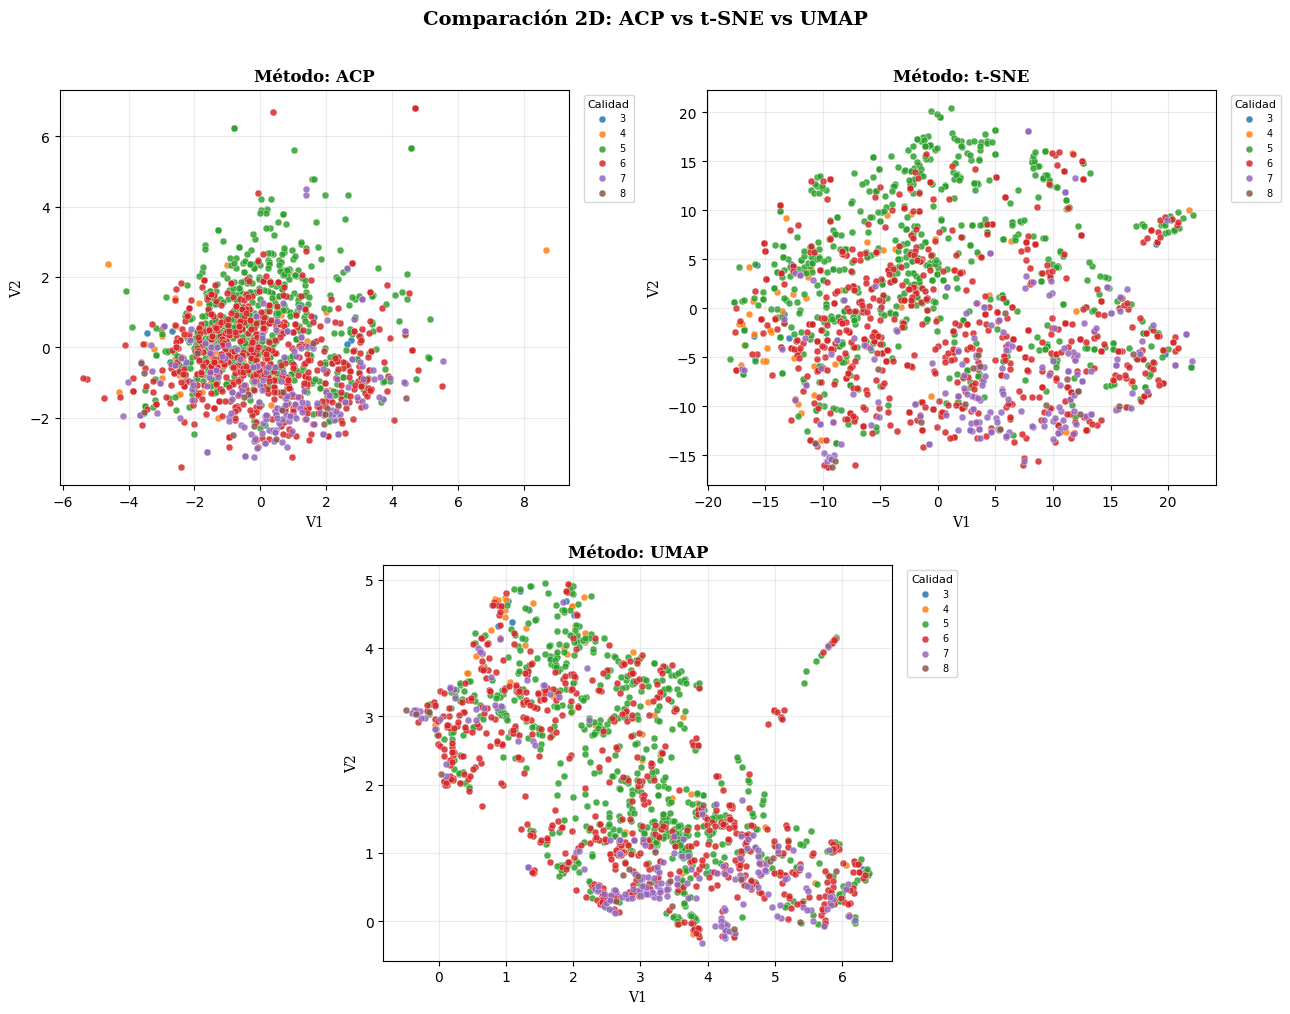

In [3]:
importlib.reload(winequality)
from scripts.Dataset_2 import acp, tsne, umap, graficar_comparacion_2d

resultado_acp, modelo_acp = acp(df2, n_components=3, graficar=False)
resultado_tsne           = tsne(df2, n_components=3, graficar=False)
resultado_umap, mejor_n  = umap(df2, n_components=3, graficar=False)

graficar_comparacion_2d(resultado_acp, resultado_tsne, resultado_umap)

<div style="margin: 24px 0; padding: 20px 24px; border: 1px solid #e0e0e0; border-left: 4px solid #b85300; background:#fafafa;">
  <p style="font-family:'Courier New', monospace; font-size:0.72em; color:#b85300; text-transform:uppercase; letter-spacing:1.5px; margin:0 0 8px;">Interpretación</p>
  <p style="font-family:'Palatino Linotype', Palatino, serif; font-size:1.05em; color:#000; font-weight:600; margin:0 0 12px;">¿Qué método separa mejor los niveles de calidad del vino en 2D?</p>
  <p style="font-family:'Palatino Linotype', Palatino, serif; font-size:0.95em; color:#333; line-height:1.75; margin:8px 0;">Las gráficas 2D revelan un patrón consistente en los tres métodos: las calidades extremas (3–4 y 8) tienden a situarse en los bordes del espacio proyectado, mientras que las calidades centrales (5, 6 y 7) se solapan en una zona densa al centro.</p><p style="font-family:'Palatino Linotype', Palatino, serif; font-size:0.95em; color:#333; line-height:1.75; margin:8px 0;"><strong>ACP</strong> muestra los puntos más entremezclados sin fronteras visibles entre niveles de calidad. Esto es esperable porque las diferencias fisicoquímicas entre vinos adyacentes son graduales y no lineales: ACP solo captura la mayor varianza global sin considerar la separación entre clases.</p><p style="font-family:'Palatino Linotype', Palatino, serif; font-size:0.95em; color:#333; line-height:1.75; margin:8px 0;"><strong>t-SNE</strong> forma agrupaciones localmente más compactas. Los clusters de calidades adyacentes (5 y 6, 6 y 7) siguen solapándose porque son categorías continuas, pero las calidades extremas aparecen más alejadas del núcleo central.</p><p style="font-family:'Palatino Linotype', Palatino, serif; font-size:0.95em; color:#333; line-height:1.75; margin:8px 0;"><strong>UMAP</strong> muestra la mejor separación de los tres: mayor distancia entre calidades extremas y una gradación más clara de bajo a alto en el espacio proyectado, aunque el solapamiento en calidades 5–6 persiste por ser las clases más ambiguas del dataset.</p>
</div>

<div style="margin: 40px 0 8px; border-left: 3px solid #b85300; padding-left: 16px;">
  <span style="font-family:'Courier New', monospace; font-size:0.75em; color:#b85300; text-transform:uppercase; letter-spacing:1.5px;">Fase 2</span>
  <h2 style="font-family:'Palatino Linotype', Palatino, serif; font-size:1.35em; color:#000; margin:4px 0 0; font-weight:600;">Comparación 3D — ACP vs t-SNE vs UMAP</h2>
</div>

Varianza explicada por componente: [0.28173931 0.1750827  0.1409585 ]
Varianza explicada acumulada: 0.5978
Silhouette score (ACP): -0.0531
Silhouette score (t-SNE): -0.0971
Silhouette score por cantidad de vecinos: {5: -0.14342273771762848, 10: -0.1293260157108307, 15: -0.11989367008209229, 20: -0.11745196580886841, 30: -0.1203043982386589, 50: -0.11716680973768234}
Mejor cantidad de vecinos: 50 (silhouette score: -0.1172)


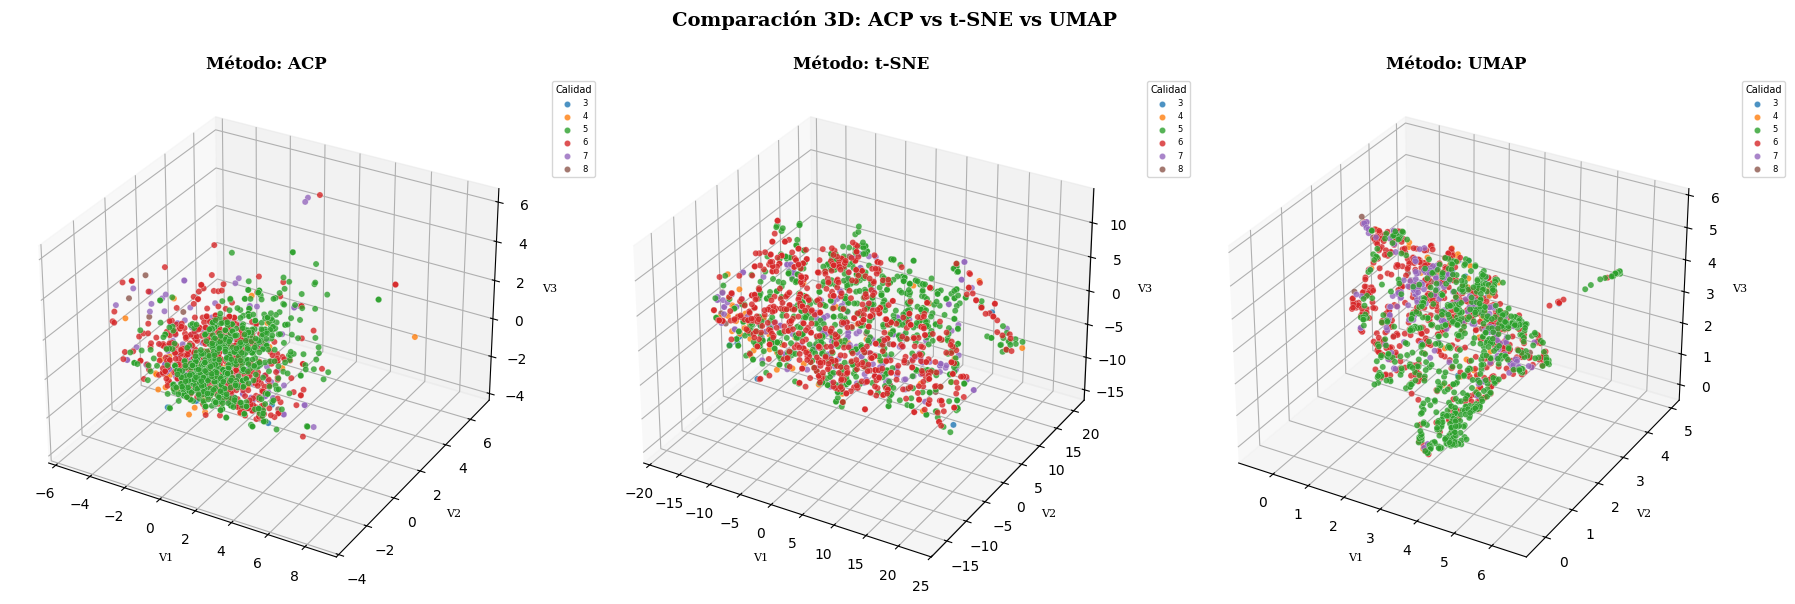

In [4]:
from scripts.Dataset_2 import acp, tsne, umap, graficar_comparacion_3d

resultado_acp, modelo_acp = acp(df2, graficar=False)
resultado_tsne           = tsne(df2, graficar=False)
resultado_umap, mejor_n  = umap(df2, graficar=False)

graficar_comparacion_3d(resultado_acp, resultado_tsne, resultado_umap)

In [6]:
from sklearn.metrics import silhouette_score

print('ACP 3D:  ', silhouette_score(resultado_acp.drop(columns='calidad'),  resultado_acp['calidad']))
print('t-SNE 3D:', silhouette_score(resultado_tsne.drop(columns='calidad'), resultado_tsne['calidad']))
print('UMAP 3D: ', silhouette_score(resultado_umap.drop(columns='calidad'), resultado_umap['calidad']))

ACP 3D:   -0.05306663011581302
t-SNE 3D: -0.0971442237496376
UMAP 3D:  -0.11716680973768234


<div style="margin: 24px 0; padding: 20px 24px; border: 1px solid #e0e0e0; border-left: 4px solid #b85300; background:#fafafa;">
  <p style="font-family:'Courier New', monospace; font-size:0.72em; color:#b85300; text-transform:uppercase; letter-spacing:1.5px; margin:0 0 8px;">Interpretación</p>
  <p style="font-family:'Palatino Linotype', Palatino, serif; font-size:1.05em; color:#000; font-weight:600; margin:0 0 12px;">¿Qué método separa mejor los niveles de calidad del vino en 3D?</p>
  <p style="font-family:'Palatino Linotype', Palatino, serif; font-size:0.95em; color:#333; line-height:1.75; margin:8px 0;">La vista 3D añade profundidad a la exploración y permite rotar los clusters para encontrar ángulos donde la separación es más evidente. Sin embargo, el patrón fundamental se mantiene: los métodos no lineales superan a ACP y UMAP lidera la separación.</p><p style="font-family:'Palatino Linotype', Palatino, serif; font-size:0.95em; color:#333; line-height:1.75; margin:8px 0;"><strong>ACP en 3D</strong> mejora modestamente respecto a 2D al incorporar una tercera componente que captura algo de la varianza no recogida antes. Aun así, la proyección sigue siendo demasiado lineal para distinguir las graduaciones finas de calidad del vino.</p><p style="font-family:'Palatino Linotype', Palatino, serif; font-size:0.95em; color:#333; line-height:1.75; margin:8px 0;"><strong>t-SNE en 3D</strong> puede mostrar clusters más diferenciados en ciertos ángulos de rotación, pero su falta de preservación de estructura global hace que la interpretación varíe según el punto de vista.</p><p style="font-family:'Palatino Linotype', Palatino, serif; font-size:0.95em; color:#333; line-height:1.75; margin:8px 0;"><strong>UMAP en 3D</strong> ofrece la representación más coherente: la gradación de calidad tiende a distribuirse a lo largo de un eje interpretable del espacio, lo que facilita identificar vinos de alta y baja calidad con mayor confianza.</p><p style="font-family:'Palatino Linotype', Palatino, serif; font-size:0.95em; color:#333; line-height:1.75; margin:8px 0;"><strong>Conclusión:</strong> En winequality, ningún método consigue clusters perfectamente separados porque las clases son intrínsecamente continuas. UMAP destaca al revelar la estructura gradual de calidad mejor que los otros dos, siendo útil para análisis exploratorio y selección de variables.</p>
</div>

<hr style="border:none; border-top:1px solid #e0e0e0; margin:48px 0 0;">